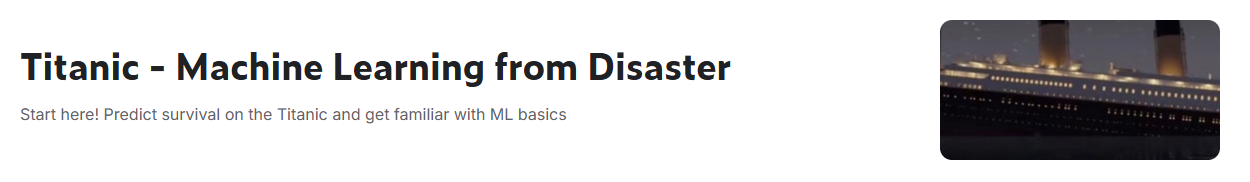

* https://www.kaggle.com/competitions/titanic/leaderboard

<pre>

survival  Survival	0 = No, 1 = Yes
pclass	  Ticket class	1 = 1st, 2 = 2nd, 3 = 3rd
sex   	  Sex	
Age	  Age in years	
sibsp	  # of siblings / spouses aboard the Titanic	
parch	  # of parents / children aboard the Titanic	
ticket	  Ticket number	
fare	  Passenger fare	
cabin	  Cabin number	
embarked  Port of Embarkation	C = Cherbourg, Q = Queenstown, S = Southampton

In [1]:
from sklearn import set_config
set_config(display="text")          #인코딩 텍스트로 바꿔달라는

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import warnings
warnings.filterwarnings('ignore')


#----------차트 속성 (한글처리/그리드)
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False



#----------문제/답 분리
from sklearn.model_selection import train_test_split 


#----------분류모델
from sklearn.linear_model import LogisticRegression   #선형모델 
from sklearn.ensemble import RandomForestClassifier   #트리모델

#----------모델결합(Ensembles)
from sklearn.ensemble import VotingClassifier, VotingRegressor


#----------교차검증
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold


#----------평가 매트릭스
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, classification_report


#----------인코딩(글자->숫자)
from sklearn.preprocessing import LabelEncoder, OneHotEncoder


#----------정규화(스케일링)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler 


#----------차원 축소
from sklearn.decomposition import PCA 

# **[1] Data Load**

In [3]:
train = pd.read_csv("../../Datas/#titanic/train.csv") 
test = pd.read_csv("../../Datas/#titanic/test.csv")
sub = pd.read_csv("../../Datas/#titanic/gender_submission.csv")

## **데이터 수정**

### 컬럼 소문자 변경

In [4]:
train.columns = train.columns.str.lower()
test.columns = test.columns.str.lower()

### ['passengerid'] 컬럼 삭제

In [5]:
train = train.drop(columns=['passengerid'])
test = test.drop(columns=['passengerid'])

In [6]:
train.head(2)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [7]:
test.head(2)

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S


In [8]:
sub.head(2)

,PassengerId,Survived
0,892,0
1,893,1


In [9]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   name      891 non-null    str    
 3   sex       891 non-null    str    
 4   age       714 non-null    float64
 5   sibsp     891 non-null    int64  
 6   parch     891 non-null    int64  
 7   ticket    891 non-null    str    
 8   fare      891 non-null    float64
 9   cabin     204 non-null    str    
 10  embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 76.7 KB


In [10]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    418 non-null    int64  
 1   name      418 non-null    str    
 2   sex       418 non-null    str    
 3   age       332 non-null    float64
 4   sibsp     418 non-null    int64  
 5   parch     418 non-null    int64  
 6   ticket    418 non-null    str    
 7   fare      417 non-null    float64
 8   cabin     91 non-null     str    
 9   embarked  418 non-null    str    
dtypes: float64(2), int64(3), str(5)
memory usage: 32.8 KB


* <font color='red'> 결측 있음 > 보간
* <font color='red'> 글자 있음 > 인코딩

# **[2] 1차 EDA(Exploratory Data Analysis)**

* name : 호칭 분류
* sex : male(0), female(1)
* age : 결측처리 필요
* sibsp, parch : 파생피쳐 생성(family_cnt) - 일행 total 인원수
* fare : 파생피쳐 생성(fare_rate) - 1인 요금 확인
* cabin & pclass & fare/fare_rate와의 관계 확인
* embarked : S(0), C(1), Q(2) --> 인코딩

## **시각화 hist()**
* 데이터 분포도 확인(왜도, 첨도, 정규분포)

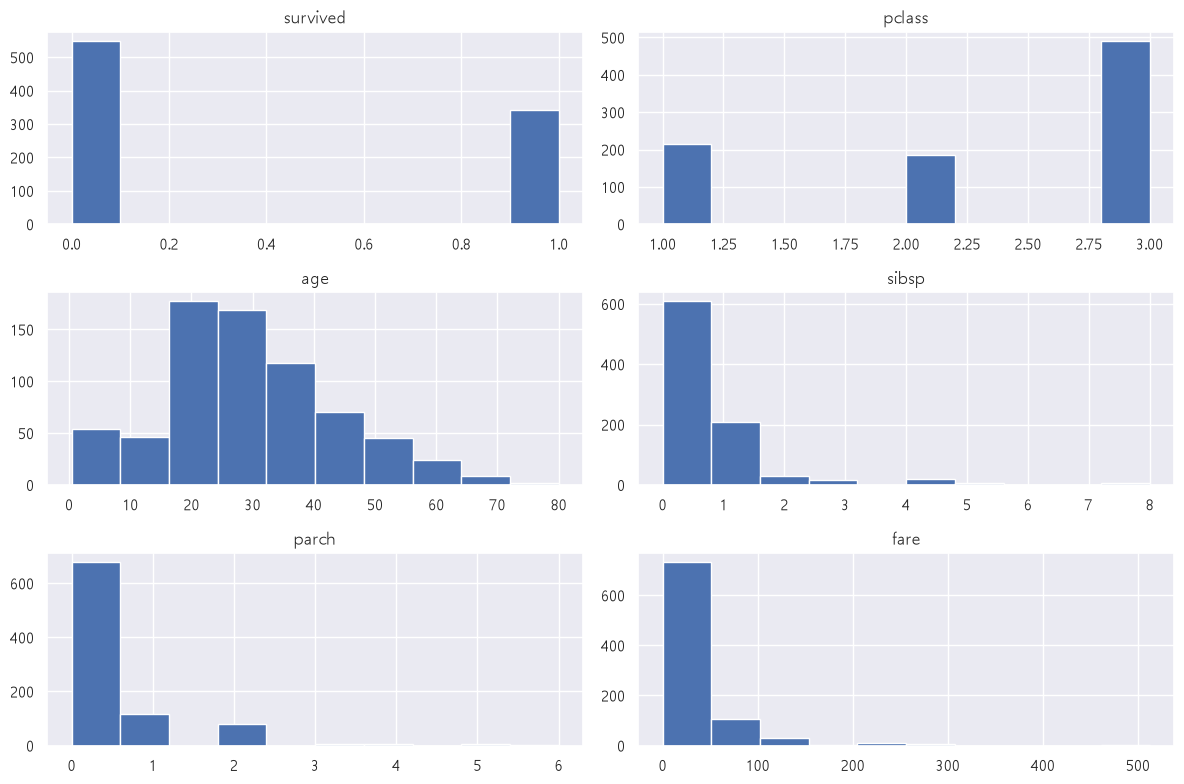

In [11]:
train.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

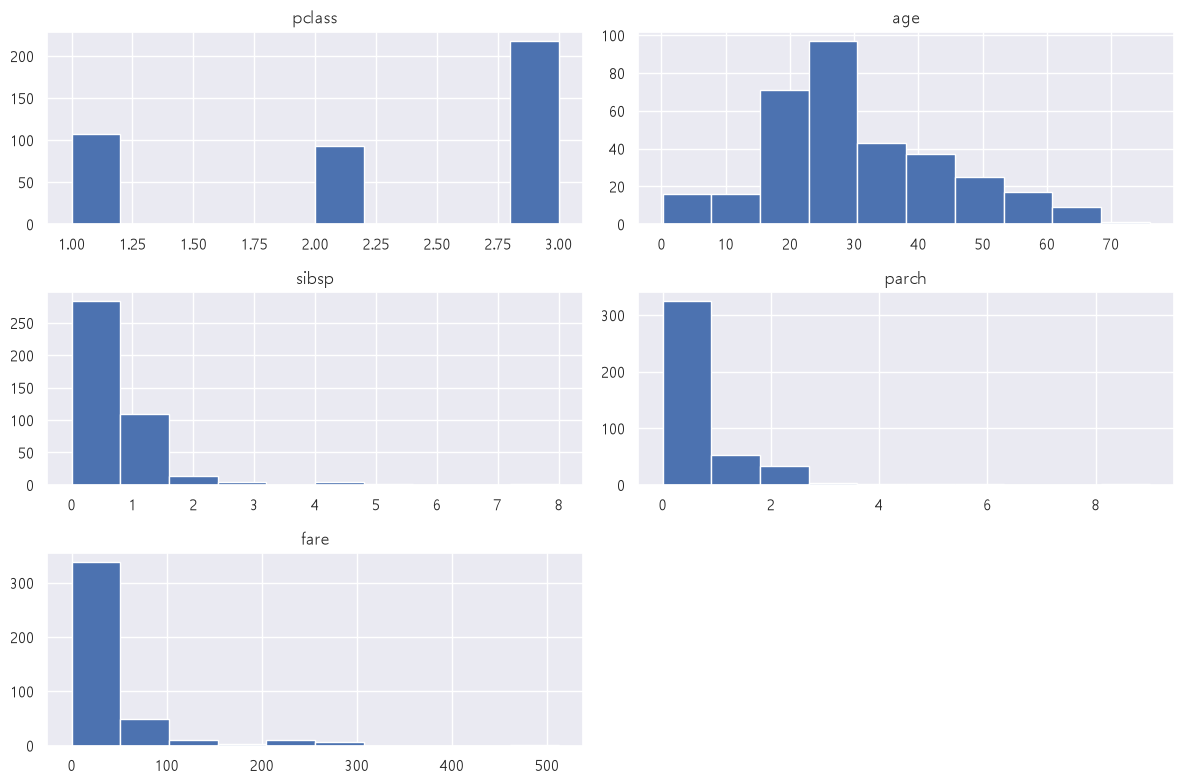

In [12]:
test.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

# **[3] 1차 전처리&가공**

* sex : male(0), female(1) --> 인코딩
* embarked : S(0) C(1) Q(2)  --> 인코딩
* 결측처리
    * age
    * cabin
    * embarked
    * fare(test)
* 파생피쳐
    * family_cnt = sibsp + parch + 1
    * age_group(나이대)
    * fare_rate(1인 요금)
* name : 호칭분류
* cabin : pclass , fare , fare_rate 와의 관계 -- EDA

## **인코딩 처리 : sex, embarked**
* 범주형(카테고리형) 데이터의 글자를 숫자로 변환  --- ex) 상중하, 대중소 등

### <font color=blue>**방법1) map()**

In [13]:
traincp = train.copy()
traincp['sex'] = traincp['sex'].map({"male":0, "female":1})
traincp.head(2)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C


### 방법2) replace()

In [14]:
traincp = train.copy()
traincp['sex'] = traincp['sex'].replace(["male", "female"], [0, 1])
traincp.head(2)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C


### 방법3) apply (lambda x : )

In [15]:
traincp = train.copy()
traincp['sex'] = traincp['sex'].apply(lambda s : 0 if s == 'male' else 1)
traincp.head(2)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C


### 방법4) LabelEncoder()
* https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html#sklearn.preprocessing.LabelEncoder
* 알파벳 순서대로 0부터 인코딩 

In [16]:
le = LabelEncoder()
traincp = train.copy()
le.fit(traincp['sex'])
traincp['sex'] = le.transform(traincp['sex'])
traincp.head(2)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C


### 방법5) OneHotEncoder()
* https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html
* <font color=red> 2D만 fit() 가능
* OneHotEncoder : 각 값마다의 영향도 분석까지 하고싶을 때

In [17]:
oh = OneHotEncoder(sparse_output=False, dtype=int)     #--------각각 고유한 0, 1이 아닌 0 1, 1 0 이런식으로 출력  /  소수점 아니고 숫자로
oh.fit(traincp[['sex']])  
res = oh.transform(traincp[['sex']])
res

array([[0, 1],
       [1, 0],
       [1, 0],
       ...,
       [1, 0],
       [0, 1],
       [0, 1]], shape=(891, 2))

In [18]:
oh.get_feature_names_out(['sex'])    #-----원핫인코딩 후 값의 개수에 따라 컬럼을 새로 만듬

array(['sex_0', 'sex_1'], dtype=object)

In [19]:
#-------원핫인코딩 결과를 DataFrame으로 변환
temp = pd.DataFrame(res, columns=oh.get_feature_names_out(['sex']))
print(temp.shape, train.shape)
temp.head(2)

# 컬럼으로 추가하는 이유 : 알파벳순으로 소팅해서 값을 매기기 때문에 서열의 존재를 없애기 위해 (높은값을 더 중요하다고 학습하는 것을 방지하기 위해)

(891, 2) (891, 11)


,sex_0,sex_1
0,0,1
1,1,0


In [20]:
traincp = pd.concat([traincp, temp], axis=1)
traincp.head(2)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,sex_0,sex_1
0,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S,0,1
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C,1,0


### 방법6) pd.get_dummies()
* onehotencoder + get_features + concat 과 같은 문법
* dtype=int 지정 안 하면 : 기본값은 True/False로 출력됨
* <font color=red> 자동으로 원본의 동일 컬럼 drop 해줌

In [21]:
traincp = train.copy()
traincp = pd.get_dummies(traincp, columns=['sex'], dtype=int)
traincp.head(2)

,survived,pclass,name,age,sibsp,parch,ticket,fare,cabin,embarked,sex_female,sex_male
0,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,S,0,1
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,C,1,0


### <font color=blue>**원본적용**

In [22]:
train['sex'] = train['sex'].map({"male":0, "female":1})
test['sex'] = test['sex'].map({"male":0, "female":1})

In [23]:
train['embarked'] = train['embarked'].map({"S":0, "C":1, "Q":2})
test['embarked'] = test['embarked'].map({"S":0, "C":1, "Q":2})

In [24]:
train.head(2)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,0.0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,1.0


In [25]:
test.head(2)

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,3,"Kelly, Mr. James",0,34.5,0,0,330911,7.8292,NaN,2
1,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,7.0000,NaN,0


## **호칭정리**
* ", ____. "
* r : 정규표현식 기호
* \s : space
* \. : . 찾기
* (\w+) : 한글자 이상 찾기 (*공백없는 것만 가능)
* ([^\.]+) : 공백 포함 단어 찾기

In [26]:
traincp = train.copy()
testcp = test.copy()

train['name'] = traincp['name'].str.extract(r',\s([^\.]+)\.')
test['name'] = testcp['name'].str.extract(r',\s([^\.]+)\.')

train.head(2)
test.head(2)

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,3,Mr,0,34.5,0,0,330911,7.8292,NaN,2
1,3,Mrs,1,47.0,1,0,363272,7.0000,NaN,0


In [27]:
train['name'].value_counts()
test['name'].value_counts()

name
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64

<font color=blue> <b> ▼ 정리
* Mr : Mr, Sir, Capt, Jonkheer, Dr , Rev, Major, Col, Don  
* Mrs : Mrs, Mme, Dona
* Miss : Miss, Mlle, Ms, Lady
* Master : Master

In [28]:
mydict = { 
    'Mr': 'Mr', 'Sir': 'Mr', 'Capt': 'Mr', 'Jonkheer': 'Mr', 'Dr': 'Mr', 'Rev': 'Mr', 'Major': 'Mr', 'Col': 'Mr', 'Don': 'Mr', 'the Countess': 'Mr',
    'Mrs': 'Mrs', 'Mme': 'Mrs', 'Dona': 'Mrs', 
    'Miss': 'Miss', 'Mlle': 'Miss', 'Ms': 'Miss', 'Lady': 'Miss', 
    'Master': 'Master' 
        }

### <font color=blue>**원본적용**

In [29]:
#---------풀네임에서 호칭 자르기
train['name'] = traincp['name'].str.extract(r',\s([^\.]+)\.')
test['name'] = testcp['name'].str.extract(r',\s([^\.]+)\.')

#---------호칭 정리
train['name'] = train['name'].map(mydict)
test['name'] = test['name'].map(mydict)

#---------인코딩
train['name'] = train['name'].map({"Mr":0, "Miss":1, "Mrs":2, "Master":3})
test['name'] = test['name'].map({"Mr":0, "Miss":1, "Mrs":2, "Master":3})

In [30]:
train['name'].value_counts()

name
0    539
1    186
2    126
3     40
Name: count, dtype: int64

In [31]:
test['name'].value_counts()

name
0    245
1     79
2     73
3     21
Name: count, dtype: int64

## **결측처리 1차**
* age, cabin, embarked

In [32]:
s = train.isna().sum()
s[s > 0]

age         177
cabin       687
embarked      2
dtype: int64

### age : 호칭별 평균 나이
* <font color=red> **transform()** </font> : 적은 양으로 많은 양의 데이터를 채울 때

In [33]:
np.round(train.groupby("name")['age'].mean(), 1)     #--------호칭(name)별 평균값을 소수점 1자리 반올림

name
0    33.0
1    22.0
2    35.8
3     4.6
Name: age, dtype: float64

In [34]:
train['age'] = train['age'].fillna( np.round (train.groupby("name")['age'].transform('mean'), 1) )
test['age'] = test['age'].fillna( np.round (test.groupby("name")['age'].transform('mean'), 1) )

### embarked : 최빈도값
* S(0)로 채우기
* <font color=red> <b> mode() : Series로 값 출력 --> 정확히 값을 빼려면 mode().values[0]

In [35]:
train['embarked'].value_counts()

embarked
0.0    644
1.0    168
2.0     77
Name: count, dtype: int64

In [36]:
train['embarked'].mode()

0    0.0
Name: embarked, dtype: float64

In [37]:
train['embarked'].mode().values

array([0.])

In [38]:
print(train['embarked'].mode().values[0])

0.0


In [39]:
train['embarked'] = train['embarked'].fillna(train['embarked'].mode().values[0])

In [40]:
train.head(2)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,0,0,22.0,1,0,A/5 21171,7.2500,NaN,0.0
1,1,1,2,1,38.0,1,0,PC 17599,71.2833,C85,1.0


* test_fare 결측값 = 무임승차??????

In [41]:
train.isna().sum()

survived      0
pclass        0
name          0
sex           0
age           0
sibsp         0
parch         0
ticket        0
fare          0
cabin       687
embarked      0
dtype: int64

In [42]:
test.isna().sum()

pclass        0
name          0
sex           0
age           0
sibsp         0
parch         0
ticket        0
fare          1
cabin       327
embarked      0
dtype: int64

In [43]:
test[test['fare'].isna()]

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
152,3,0,0,60.5,0,0,3701,NaN,NaN,0


## **불필요한 컬럼 삭제**

### ticket, cabin : 삭제

In [44]:
train['cabin'].value_counts()

cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

In [45]:
train[['pclass', 'cabin', 'ticket']].value_counts()

pclass  cabin        ticket  
1       C23 C25 C27  19950       4
        B96 B98      113760      4
2       F2           230080      3
1       C22 C26      113781      3
        C123         113803      2
                                ..
        A24          PC 17590    1
        B51 B53 B55  695         1
        C50          11767       1
        B42          112053      1
        C148         111369      1
Name: count, Length: 161, dtype: int64

In [46]:
train = train.drop(columns=['ticket', 'cabin'])

In [47]:
test = test.drop(columns=['ticket', 'cabin'])

In [48]:
train.head(2)

,survived,pclass,name,sex,age,sibsp,parch,fare,embarked
0,0,3,0,0,22.0,1,0,7.2500,0.0
1,1,1,2,1,38.0,1,0,71.2833,1.0


In [49]:
test.head(2)

,pclass,name,sex,age,sibsp,parch,fare,embarked
0,3,0,0,34.5,0,0,7.8292,2
1,3,2,1,47.0,1,0,7.0000,0


## **파생피쳐 생성**

### age_group

In [50]:
train["age_group"] = train["age"]//10

### 총 가족수(family_cnt), 1인 요금(fare_rate)

In [51]:
train['family_cnt'] = train['sibsp'] + train['parch'] + 1
train['fare_rate'] = train['fare'] / train['family_cnt']

In [52]:
train.head(2)

,survived,pclass,name,sex,age,sibsp,parch,fare,embarked,age_group,family_cnt,fare_rate
0,0,3,0,0,22.0,1,0,7.2500,0.0,2.0,2,3.62500
1,1,1,2,1,38.0,1,0,71.2833,1.0,3.0,2,35.64165


In [53]:
test["age_group"] = test["age"]//10
test['family_cnt'] = test['sibsp'] + test['parch'] + 1
test['fare_rate'] = test['fare'] / test['family_cnt']

## **결측처리 2차**

### fare : 평균요금
* 파생피쳐 생성 후 평균요금 계산  
* family_cnt == 1
* pclass = 3

In [54]:
test[test['fare'].isna()]

,pclass,name,sex,age,sibsp,parch,fare,embarked,age_group,family_cnt,fare_rate
152,3,0,0,60.5,0,0,NaN,0,6.0,1,NaN


In [55]:
train[(train['family_cnt'] == 1) & (train['pclass'] == 3)]['fare'].mean()

np.float64(9.272051851851852)

In [56]:
v = train[(train['family_cnt'] == 1) & (train['pclass'] == 3)]['fare'].mean()
test['fare'] = test['fare'].fillna(v)

In [57]:
test['fare_rate'] = test['fare'] / test['family_cnt']

## **→ 가공처리 후 최종데이터**

In [58]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    891 non-null    int64  
 1   pclass      891 non-null    int64  
 2   name        891 non-null    int64  
 3   sex         891 non-null    int64  
 4   age         891 non-null    float64
 5   sibsp       891 non-null    int64  
 6   parch       891 non-null    int64  
 7   fare        891 non-null    float64
 8   embarked    891 non-null    float64
 9   age_group   891 non-null    float64
 10  family_cnt  891 non-null    int64  
 11  fare_rate   891 non-null    float64
dtypes: float64(5), int64(7)
memory usage: 83.7 KB


In [59]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pclass      418 non-null    int64  
 1   name        418 non-null    int64  
 2   sex         418 non-null    int64  
 3   age         418 non-null    float64
 4   sibsp       418 non-null    int64  
 5   parch       418 non-null    int64  
 6   fare        418 non-null    float64
 7   embarked    418 non-null    int64  
 8   age_group   418 non-null    float64
 9   family_cnt  418 non-null    int64  
 10  fare_rate   418 non-null    float64
dtypes: float64(4), int64(7)
memory usage: 36.1 KB


In [60]:
train.head(2)

,survived,pclass,name,sex,age,sibsp,parch,fare,embarked,age_group,family_cnt,fare_rate
0,0,3,0,0,22.0,1,0,7.2500,0.0,2.0,2,3.62500
1,1,1,2,1,38.0,1,0,71.2833,1.0,3.0,2,35.64165


# **[4] 공통함수**

In [61]:
def myscore(X_train7, y_train7, X_test3, y_test3, model=None) :
    if model is None : 
        model = RandomForestClassifier(
            n_estimators=100,
            random_state=1234
        )
    print(model.__class__.__name__)    
    model.fit(X_train7, y_train7)
    pred = model.predict(X_test3)

    acc = accuracy_score(y_test3, pred)
    print( f"acc : {acc:.4f}" )

In [83]:
def myscore222(df, model=None, MY_TARGET="survived") :
    X = df.drop(columns=['survived'])
    y = df[MY_TARGET]
    X_train7, X_test3,    y_train7, y_test3 = train_test_split( X, y, test_size=0.3, random_state=1234, shuffle=True)
    
    if model is None : 
            model = RandomForestClassifier(
                n_estimators=100,
                random_state=1234
            )
    print(model.__class__.__name__) 
    
    model.fit(X_train7, y_train7)
    pred = model.predict(X_test3)
    
    acc = accuracy_score(y_test3, pred)
    print( f"acc : {acc:.4f}" )

    cm = confusion_matrix(y_test3, pred)
    print( cm )

    return model

# <font color=darkorange> **※1차 점수※**

In [63]:
model = myscore222(train)

RandomForestClassifier
acc : 0.8097


RandomForestClassifier
acc : 0.8097


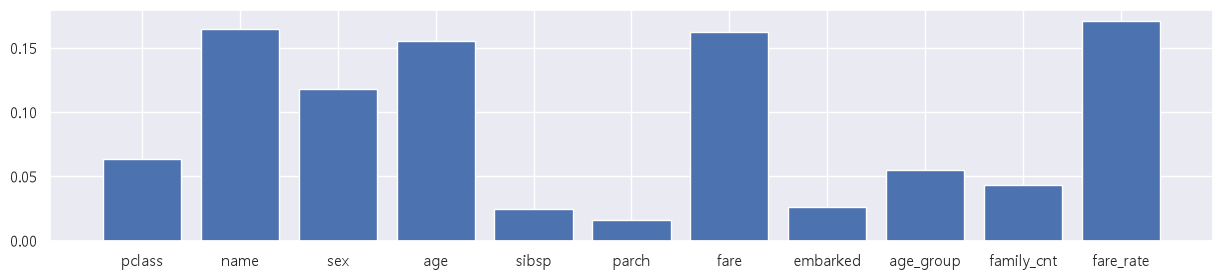

In [64]:
model = myscore222(train)
imp = model.feature_importances_
# print(imp)
# print(X_train7.columns)

plt.figure(figsize=(15,3))

plt.bar(test.columns, imp, label="블루")
plt.tight_layout
plt.show()

In [65]:
# lr = LogisticRegression()
# model2 = myscore222(train, model=lr)

XGBClassifier
acc : 0.8321


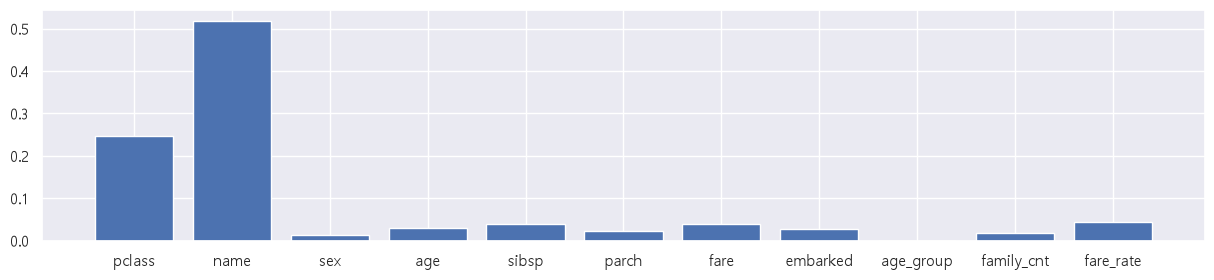

In [66]:
from xgboost import XGBRegressor, XGBClassifier    #----Regressor 회귀 / Classifier 분류
xgb = XGBClassifier()


model = myscore222(train, xgb)
imp = model.feature_importances_
# print(imp)
# print(X_train7.columns)

plt.figure(figsize=(15,3))

plt.bar(test.columns, imp, label="블루")
plt.tight_layout
plt.show()

LGBMClassifier
[LightGBM] [Info] Number of positive: 240, number of negative: 383
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000087 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 323
[LightGBM] [Info] Number of data points in the train set: 623, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.385233 -> initscore=-0.467396
[LightGBM] [Info] Start training from score -0.467396
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

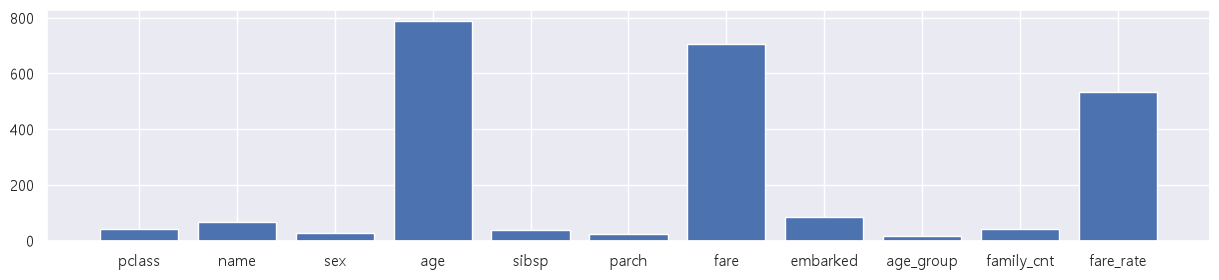

In [67]:
from lightgbm import LGBMRegressor, LGBMClassifier
lgb = LGBMClassifier()

model = myscore222(train, lgb)
imp = model.feature_importances_
# print(imp)
# print(X_train7.columns)

plt.figure(figsize=(15,3))

plt.bar(test.columns, imp, label="블루")
plt.tight_layout
plt.show()

# **[5] 2차 EDA(Exploratory Data Analysis)**

## **상관분석 > 인코딩 처리 후**
* <font color=red> str 피쳐는 상관분석 불가 > 인코딩 처리 후 분석
* 상관분석은 선형관계만 잘 잡음
* <font color=red><b>피어슨 vs 스피어만
    * 연속형 변수 간의 직선 관계를 보는 피어슨 상관분석과 순위 데이터를 다루는 스피어만 상관분석

### **피어슨 상관분석 : 선형관계**
* method 별도 지정 안 하면 기본 피어슨

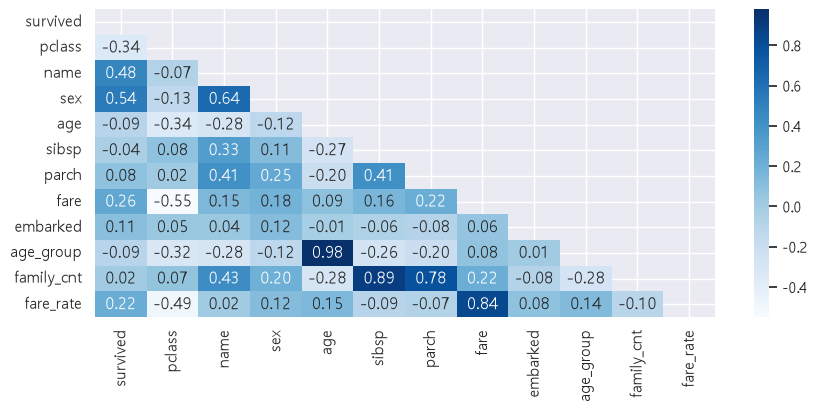

In [68]:
plt.figure(figsize=(10, 4))

# 반쪽으로 보기
mask = np.triu(np.ones_like(train.corr(), dtype=bool))
sns.heatmap(train.corr(), annot=True, fmt=".2f", cmap="Blues", mask=mask)    #.2f = 소수점 2자리까지~ (d=숫자로)
plt.show()
# test에는 타겟피쳐가 없기 때문에 train만 봐도 됨

### **스피어만 상관분석 : 순위데이터**
* method='spearman'

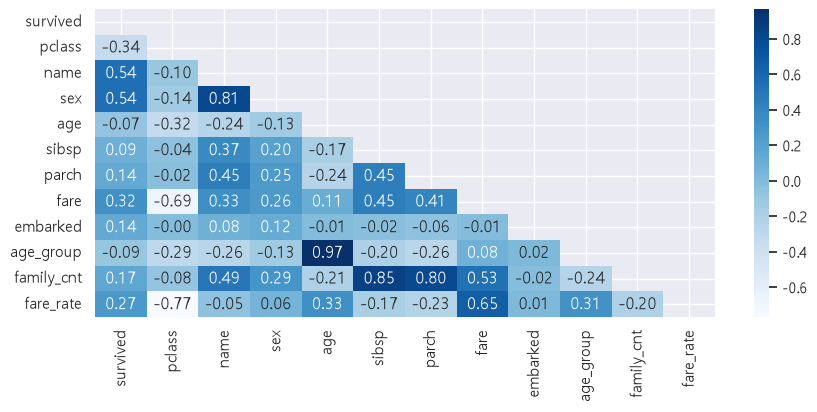

In [69]:
plt.figure(figsize=(10, 4))

mask = np.triu(np.ones_like(train.corr(), dtype=bool))
sns.heatmap(train.corr(method='spearman'), annot=True, fmt=".2f", cmap="Blues", mask=mask)   
plt.show()

## **survived**

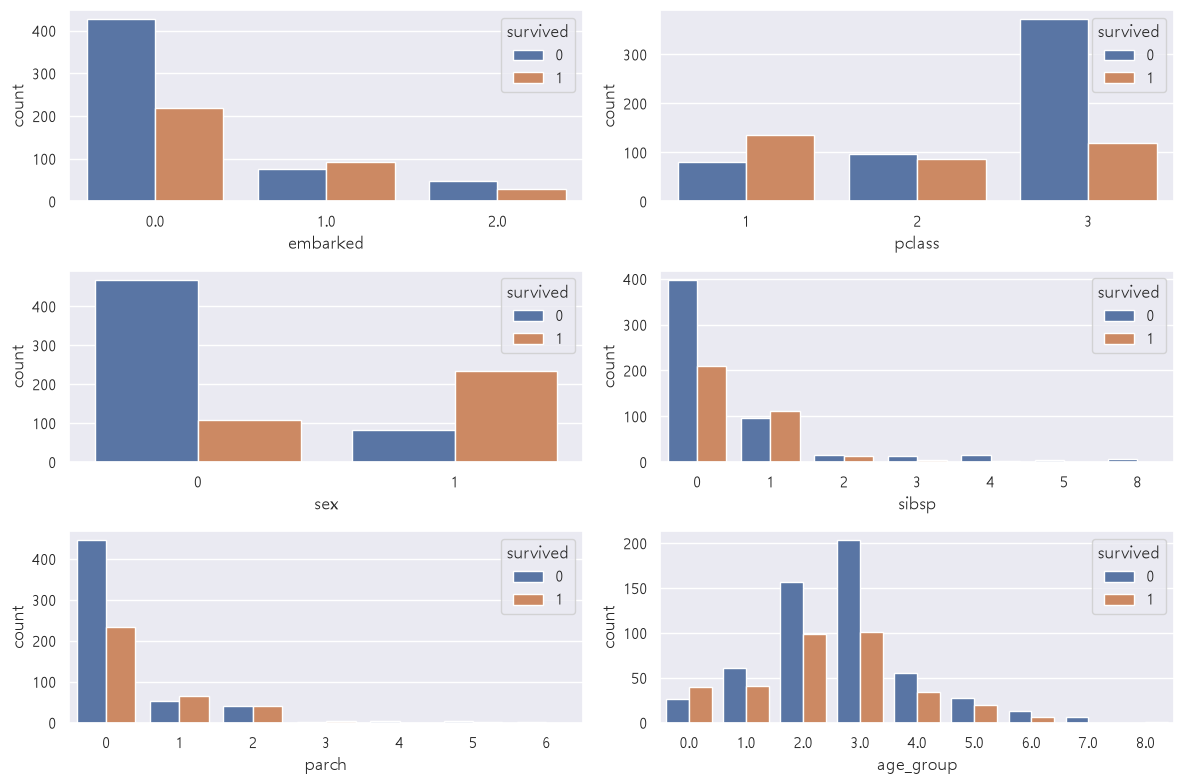

In [70]:
plt.figure(figsize=(12,8))


plt.subplot(3, 2, 1)
sns.countplot(x="embarked", hue="survived", data=train)

plt.subplot(3, 2, 2) 
sns.countplot(x="pclass", hue="survived", data=train)

plt.subplot(3, 2, 3) 
sns.countplot(x="sex", hue="survived", data=train)

plt.subplot(3, 2, 4) 
sns.countplot(x="sibsp", hue="survived", data=train)

plt.subplot(3, 2, 5) 
sns.countplot(x="parch", hue="survived", data=train)

plt.subplot(3, 2, 6) 
#train["age_group"] = train["age"]//10
sns.countplot(x="age_group", hue="survived", data=train)


plt.tight_layout()
plt.show()

<font color=blue> <b> ▼ 분석
* S에서 탄 사람, 3등급, 남자, 가족들 없이 탄 사람, 20-30대가 죽을 확률이 큼

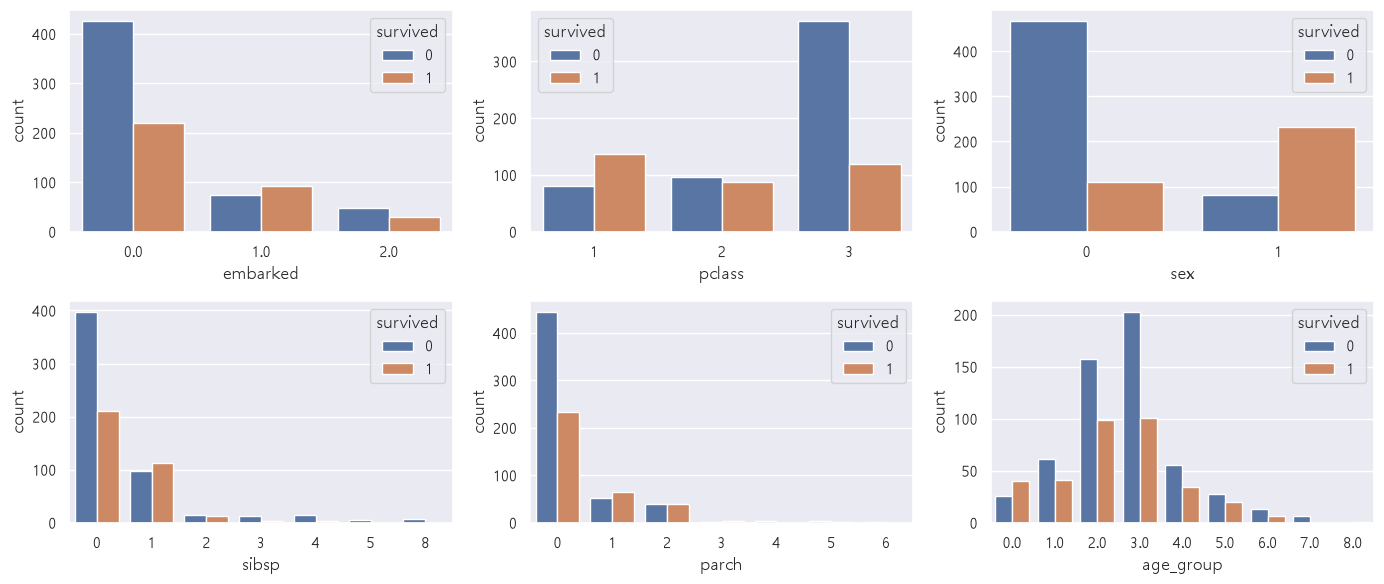

In [71]:
#for문 사용
fig, axes = plt.subplots(2,3,     figsize=(14, 6)) 
col_list=[ 'embarked', 'pclass', 'sex', 'sibsp', 'parch', 'age_group']

for i, col in enumerate(col_list) :
    줄=i//3
    칸=i%3
    sns.countplot(x=col, hue="survived", data=train,  ax=axes[줄][칸])

plt.tight_layout()
plt.show()

## **이상치(outlier) 확인**

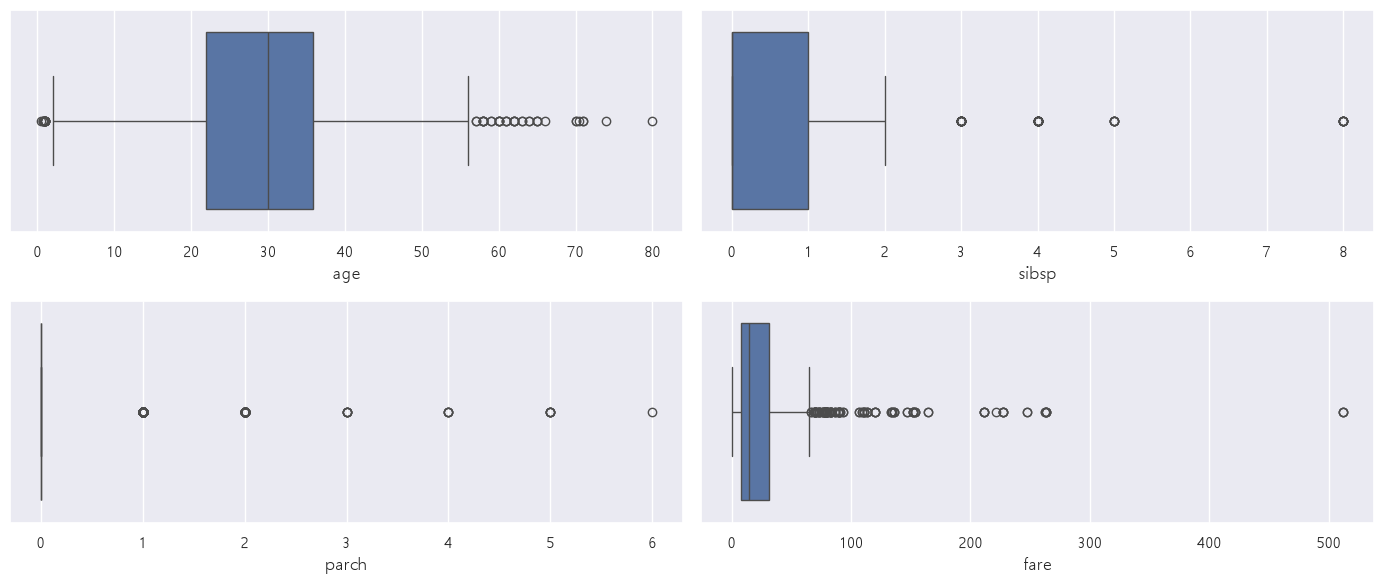

In [72]:
fig, axes = plt.subplots(2,2, figsize=(14,6))
col_list = ['age', 'sibsp', 'parch', 'fare']

for i, col in enumerate(col_list) :
    줄 = i//2 
    칸 = i%2 
    sns.boxplot(x=col, data=train, ax=axes[줄][칸])

plt.tight_layout()
plt.show()

<font color=blue> <b> ▼ 분석
* sibsp 8, fare 500 확인 필요

# **[6] 2차 전처리&가공** 
* ref) https://www.kaggle.com/code/ldfreeman3/a-data-science-framework-to-achieve-99-accuracy

## **파생피쳐 생성**
* IsAlone : 1인 여부
* FareBin : 요금 4분위 구간화

In [73]:
train['IsAlone'] = 1 
train['IsAlone'].loc[train['family_cnt'] > 1] = 0 
train['FareBin'] = pd.qcut(train['fare'], 4)

In [74]:
label = LabelEncoder()
train['FareBin'] = label.fit_transform(train['FareBin'])

# <font color=darkorange> **※2차 점수※**
* 1차 : 0.8097

In [75]:
model = myscore222(train)

RandomForestClassifier
acc : 0.8284


## **원핫인코딩 추가**
* 'sex', 'embarked', 'name' --> onehot

In [76]:
traincp = train.copy()
traincp.head(3)

,survived,pclass,name,sex,age,sibsp,parch,fare,embarked,age_group,family_cnt,fare_rate,IsAlone,FareBin
0,0,3,0,0,22.0,1,0,7.2500,0.0,2.0,2,3.62500,1,0
1,1,1,2,1,38.0,1,0,71.2833,1.0,3.0,2,35.64165,1,3
2,1,3,1,1,26.0,0,0,7.9250,0.0,2.0,1,7.92500,1,1


In [77]:
traincp = pd.get_dummies(traincp, columns=['sex', 'embarked', 'name'])
traincp.head(3)

,survived,pclass,age,sibsp,parch,fare,age_group,family_cnt,fare_rate,IsAlone,FareBin,sex_0,sex_1,embarked_0.0,embarked_1.0,embarked_2.0,name_0,name_1,name_2,name_3
0,0,3,22.0,1,0,7.2500,2.0,2,3.62500,1,0,True,False,True,False,False,True,False,False,False
1,1,1,38.0,1,0,71.2833,3.0,2,35.64165,1,3,False,True,False,True,False,False,False,True,False
2,1,3,26.0,0,0,7.9250,2.0,1,7.92500,1,1,False,True,True,False,False,False,True,False,False


# <font color=darkorange> **※3차 점수※**
* 1차 : 0.8097
* 2차 : 0.8284

In [78]:
model = myscore222(traincp)

RandomForestClassifier
acc : 0.8209


#### ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# **[7] CM : 오답분석**
* <b> 혼동 행렬(Confusion Matrix, 오차 행렬) : 분류모델에서 실제값과 예측값의 조합으로 성능을 평가하기 위한 표
* TN(True Negative) : 실제 거짓(N, 0)을 모델도 거짓(N, 0)으로 예측
* FP(False Positive) : 실제 거짓(N, 0)을 모델이 참(P, 1)으로 예측
* FN(False Negative) : 실제 참(P, 1)을 모델이 거짓(N, 0)으로 예측
* TP(True Positive) : 실제 참(P, 1)을 모델도 참(P, 1)으로 예측

``` python
sklearn.metrics.confusion_matrix(y_true, y_pred, *, labels=None, sample_weight=None, normalize=None)
sklearn.metrics.classification_report(y_true, y_pred, *, labels=None, target_names=None, sample_weight=None, digits=2, output_dict=False, zero_division='warn')

<img width=650 src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2F0LviN%2Fbtq7DUzHHX9%2FAAAAAAAAAAAAAAAAAAAAAB33aAoAd3lDxI-kKfMJUU1-LhnEXnhzpXS2UA0yMYKj%2Fimg.jpg%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1790780399%26allow_ip%3D%26allow_referer%3D%26signature%3DC%252BcX2sc9Lp5Cjo3lnAxptoSBD8I%253D">

<b> ※ accuracy_score(정확도) </b> :  정답 수 / 총 문항수    (TN+TP) / (TN+FP+FN+FP) <br>
<font color=red> <b> ※ TP를 잘 맞추는 게 제일 중요! </b> </font>  <br>

* <b> accuraty_score(정확도) </b> 
    - $\frac{(2+3)}{(2+0+1+3)}$ == $\frac{TP + TN}{TP + TN + FP + FN}$

* <b> precision_score(정밀도) </b> 
  * 모델이 참이라고 <b> 예측한 것 중 실제가 참</b>인 비율
  * <b> <font color=blue> TP</font> / (TP + <font color=blue> FP</font>)
  * <b> <font color=blue> FP가 적을수록 높은 점수
  * ex) 모델이 맞다고 한 것 중 진짜 맞는 것은 몇 퍼센트인가? <br>
  * $\frac{(3)}{(3+0)}$ == $\frac{TP}{TP + FP}$

* <b> recall_score(재현율) </b>
  * 실제가 참인 것 중 <b> 모델이 참이라고 예측</b>한 비율
  * <b> <font color=blue> TP</font>  / (TP + <font color=blue> FN</font>)
  * <b> <font color=blue> FN이 적을수록 높은 점수
  * ex) 실제로 암 환자인데 모델이 정상으로 예측한다면?! ----- 대참사
  * ex) 실제 참인 것 중 모델이 빠트리지 않고 찾아낸 것은 몇 퍼센트인가?
  * $\frac{(3)}{(3+1)}$ == $\frac{TP}{TP + FN}$

* <b> f1_score </b>
   * precision과 recall의 <b> 조화평균
   * <b> <font color=blue> 둘 다 높아야 높은 점수
   * ex) 모델이 참을 정확하게 예측하면서, 실제 참인 데이터를 놓치지 않고 잘 찾는지 평가
   * $  \frac{2* (\text{Precision} \times \text{Recall})} {\text{Precision} + \text{Recall}} $ ==  $\frac{2TP}{2TP + FP + FN}$

In [82]:
y_pred = [0, 0, 1, 1, 1, 0]
y_true = [0, 0, 1, 1, 1, 1]
res = confusion_matrix(y_true, y_pred)
print (res)

[[2 0]
 [1 3]]


In [85]:
accuracy_score(y_true, y_pred), precision_score(y_true, y_pred), recall_score(y_true, y_pred), f1_score(y_true, y_pred)

(0.8333333333333334, 1.0, 0.75, 0.8571428571428571)

In [86]:
report = classification_report(y_true, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.75      0.86         4

    accuracy                           0.83         6
   macro avg       0.83      0.88      0.83         6
weighted avg       0.89      0.83      0.84         6



In [84]:
model = myscore222(traincp)

RandomForestClassifier
acc : 0.8209
[[144  22]
 [ 26  76]]


> 144(TN), 76(TP) : 정답 <br>
> 22(FP), 26(FN) : 오답 (22 : 죽었는데(0) 살았다고(1) 예측 / 26 : 살았는데(1) 죽었다고(0) 예측)

# **[8] CV : 데이터증폭 + 튜닝**

```python
class sklearn.model_selection.GridSearchCV(estimator, param_grid, *, scoring=None, n_jobs=None, refit=True, cv=None, verbose=0, pre_dispatch='2*n_jobs', error_score=nan, return_train_score=False)
class sklearn.model_selection.KFold(n_splits=5, *, shuffle=False, random_state=None)
class sklearn.model_selection.StratifiedKFold(n_splits=5, *, shuffle=False, random_state=None)

# **[9] Ensembles : 모델결합**
* Gradient boosting, random forests
* <font color=red> <b> bagging, voting, stacking

```python
class sklearn.ensemble.VotingClassifier(estimators, *, voting='hard', weights=None, n_jobs=None, flatten_transform=True, verbose=False)
class sklearn.ensemble.VotingRegressor(estimators, *, weights=None, n_jobs=None, verbose=False)